# 02 · eda

explore the universe + build the label (fund vs its category median over the next 5 days).
run notebook 01 first. ~2k funds so we look at things by category, not one line per fund.

In [14]:
import yaml, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.width', 200, 'display.max_columns', 30)

ROOT = pathlib.Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
cfg = yaml.safe_load(open(ROOT / 'config.yaml', encoding='utf-8'))
RAW  = ROOT / cfg['paths']['raw']
prices   = pd.read_parquet(RAW / 'prices.parquet')
metadata = pd.read_parquet(RAW / 'metadata.parquet')
prices.index.name = 'date'; prices.columns.name = 'ticker'
print('prices', prices.shape, '|', metadata['category'].nunique(), 'categories')

prices (3770, 2016) | 41 categories


## universe overview

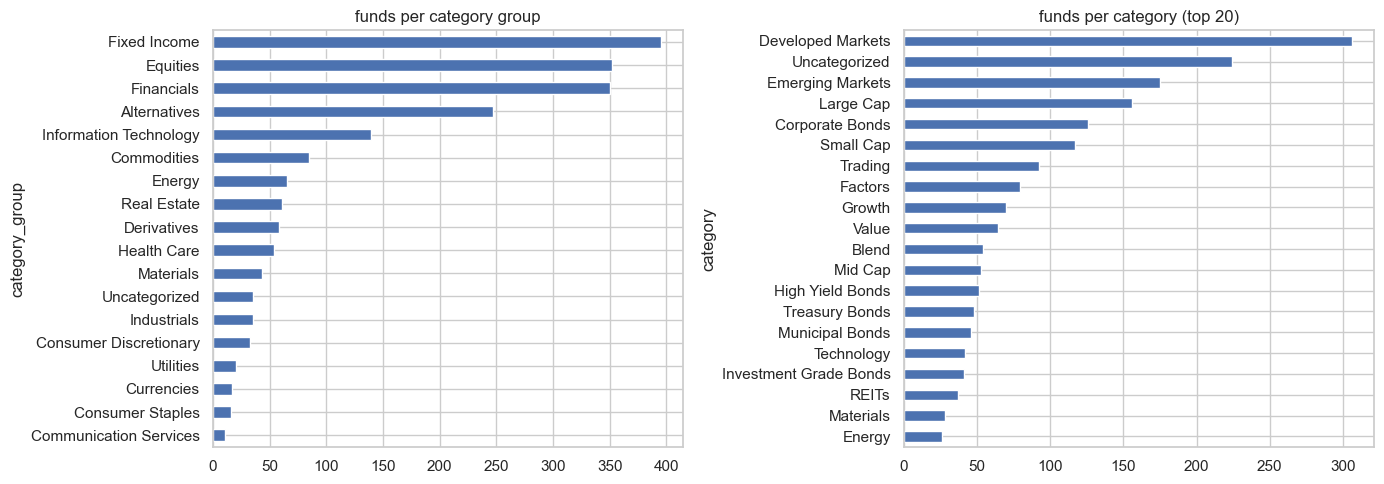

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
metadata['category_group'].value_counts().plot.barh(ax=ax[0]); ax[0].invert_yaxis(); ax[0].set_title('funds per category group')
metadata['category'].value_counts().head(20).plot.barh(ax=ax[1]); ax[1].invert_yaxis(); ax[1].set_title('funds per category (top 20)')
plt.tight_layout(); plt.show()

## history coverage

how much history does each fund actually have? most etfs are way younger than our 15y window,
so they're just empty (NaN) before they launched. thats why the raw price panel / early label
rows look 'all null' - its not a bug, those funds didnt exist yet. we drop the empty rows when
we save the labels below.

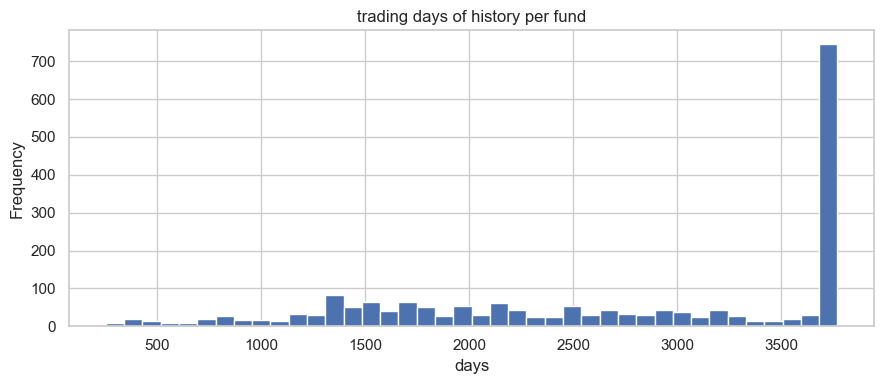

count    2016.0
mean     2687.0
std      1054.0
min       254.0
25%      1714.0
50%      2853.0
75%      3770.0
max      3770.0
dtype: float64

In [16]:
cover = prices.notna().sum()
ax = cover.plot.hist(bins=40, figsize=(9, 4)); ax.set_title('trading days of history per fund'); ax.set_xlabel('days')
plt.tight_layout(); plt.show()
cover.describe().round(0)

## the label

`rel = fund_fwd_5d_return - category_median_fwd_5d_return`, bucketed by +/- threshold.
we only label funds whose category has at least `min_group` members (else the 'median' is meaningless).

In [17]:
lcfg = cfg['labels']; h, thr, min_group = lcfg['horizon'], lcfg['threshold'], lcfg['min_group']
cat = metadata['category'].reindex(prices.columns)

# only keep funds in real categories big enough to have a meaningful median
counts = cat.value_counts()
big = counts[(counts >= min_group) & (counts.index != 'Uncategorized')].index
cols = cat[cat.isin(big)].index
px = prices[cols]; cat = cat[cols]

fwd = px.shift(-h) / px - 1.0                              # forward h-day return
cat_med = fwd.T.groupby(cat).transform('median').T         # category median, broadcast to members
rel = fwd - cat_med

label = pd.DataFrame(np.where(rel > thr, 'Outperform',
                     np.where(rel < -thr, 'Underperform', 'Neutral')),
                     index=rel.index, columns=rel.columns).where(rel.notna())
balance = pd.Series(label.values.ravel()).value_counts()
print(f'labelling {len(cols)} funds in {len(big)} categories | threshold {thr} ({thr*1e4:.0f} bps)')
balance

labelling 1786 funds in 36 categories | threshold 0.005 (50 bps)


Neutral         2334478
Underperform    1304008
Outperform      1302708
Name: count, dtype: int64

### tune the threshold

spread is way bigger than the old index-fund set

In [18]:
relf = rel.stack().dropna()
print('rel std:', round(relf.std()*1e4, 1), 'bps | abs median:', round(relf.abs().median()*1e4, 1), 'bps')
rows = []
for t in [0.001, 0.002, 0.003, 0.005, 0.0075, 0.01, 0.02]:
    up = (relf > t).mean()*100; dn = (relf < -t).mean()*100
    rows.append({'threshold_bps': t*1e4, 'Under_%': round(dn,1), 'Neutral_%': round(100-up-dn,1), 'Over_%': round(up,1)})
pd.DataFrame(rows)

rel std: 578.4 bps | abs median: 55.4 bps


,threshold_bps,Under_%,Neutral_%,Over_%
0,10.0,42.2,15.5,42.3
1,20.0,37.0,26.0,37.0
2,30.0,32.8,34.5,32.8
3,50.0,26.4,47.2,26.4
4,75.0,20.8,58.4,20.8
5,100.0,16.9,66.3,16.8
6,200.0,8.7,82.6,8.6


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
(relf.clip(-0.05, 0.05)*1e4).hist(bins=100, ax=ax[0]); ax[0].set_title('relative fwd 5d return (bps, clipped)'); ax[0].set_xlabel('bps')
balance.reindex(['Underperform','Neutral','Outperform']).plot.bar(ax=ax[1]); ax[1].set_title(f'class balance (thr={thr})')
plt.tight_layout(); plt.show()

### does dispersion differ by asset class?

bond etfs barely move, equity/leveraged ones swing a lot - so 'beating peers' means different
things per group. worth knowing before picking one global threshold.

In [ ]:
grp = metadata['category_group'].reindex(rel.columns)
disp = rel.stack().rename('rel').reset_index()
disp['group'] = disp['ticker'].map(grp)
by_grp = disp.groupby('group')['rel'].std().mul(1e4).sort_values(ascending=False)
ax = by_grp.plot.barh(figsize=(8, 6)); ax.invert_yaxis(); ax.set_title('within-category rel spread by group (bps std)')
plt.tight_layout(); plt.show()

## save labels

long table for whoever does modeling next. we only keep rows that actually have a label -
a (date, fund) pair is null when the fund didnt exist yet (big deal with 15y history: newer
etfs are blank for years) or in the last 5 days (no future price). so we drop those here,
every saved row is a real observation.

In [ ]:
def stk(df):
    s = df.stack(future_stack=True); s.index.names = ['date','ticker']; return s

labels_long = pd.concat({'fwd_ret': stk(fwd), 'cat_median': stk(cat_med),
                         'rel': stk(rel), 'label': stk(label)}, axis=1)
labels_long = labels_long.dropna(subset=['label'])          # <- drops the empty early rows
labels_long['category'] = labels_long.index.get_level_values('ticker').map(metadata['category'])
PROC = ROOT / cfg['paths']['processed']; PROC.mkdir(parents=True, exist_ok=True)
labels_long.to_parquet(PROC / 'labels.parquet')
print('saved', labels_long.shape, '- every row is a real observation')
labels_long.head()